In [10]:
using Evolutionary
using Random
using Plots

# ── Problem generator ─────────────────────────────────────────────────────────
function generate_random_tpp(n, k; random_seed = 1)
    rng = Random.MersenneTwister(random_seed)
    X = 100 * rand(rng, n)
    Y = 100 * rand(rng, n)
    d = [sqrt((X[i] - X[j])^2 + (Y[i] - Y[j])^2) for i in 1:n, j in 1:n]
    cost_item_city = 50 .+ 100 .* rand(rng, k, n)   # cost_item_city[item, city]
    return X, Y, d, cost_item_city
end

n = 100   # number of cities / markets
k = 100   # number of items to purchase
X, Y, d, cost_item_city = generate_random_tpp(n, k)
println("Generated TPP: n=$n cities, k=$k items")

Generated TPP: n=100 cities, k=100 items


In [11]:
# ── Inversion-vector encoding (same as TSP notebook) ─────────────────────────

function perm_to_inv(perm::Vector)
    N = length(perm)
    inv = zeros(Int, N)
    for i in 1:N
        m = 1
        while perm[m] != i
            if perm[m] > i
                inv[i] += 1
            end
            m += 1
        end
    end
    return inv
end

function inv_to_perm(inv::Vector)
    N = length(inv)
    pos = zeros(Int, N)
    for i in N:-1:1
        for m in (i+1):N
            if pos[m] >= inv[i] + 1
                pos[m] += 1
            end
        end
        pos[i] = inv[i] + 1
    end
    perm = zeros(Int, N)
    for i in 1:N
        perm[pos[i]] = i
    end
    return perm
end

# Sanity check
RP = randperm(20)
println("Inversion encoding roundtrip OK: ", RP == inv_to_perm(perm_to_inv(RP)))

Inversion encoding roundtrip OK: true


In [12]:
function decode_tpp(perm::Vector{Int}, d::Matrix{Float64}, cost_item_city::Matrix{Float64})
    n = size(d, 1)
    k = size(cost_item_city, 1)

    travel_cost = sum(d[perm[i], perm[mod1(i+1, n)]] for i in 1:n)

    purchase_cost = 0.0
    items_bought_at = zeros(Int, k)   # for diagnostics
    for item in 1:k
        best_price = Inf
        best_city  = perm[1]
        for city in perm
            if cost_item_city[item, city] < best_price
                best_price = cost_item_city[item, city]
                best_city  = city
            end
        end
        purchase_cost += best_price
        items_bought_at[item] = best_city
    end

    return perm, travel_cost, purchase_cost, items_bought_at
end

test_perm = collect(1:n)
_, tc0, pc0, _ = decode_tpp(test_perm, d, cost_item_city)
println("Test decode: all $n cities visited, travel=$(round(tc0,digits=2)), purchase=$(round(pc0,digits=2)), total=$(round(tc0+pc0,digits=2))")

Test decode: all 100 cities visited, travel=4935.78, purchase=5076.15, total=10011.93


In [ ]:
# ── Genetic operators ─────────────────────────────────────────────────────────

function mutate_swap_tpp(recombinant::AbstractVector;
        rng::AbstractRNG = Random.default_rng())
    N = length(recombinant)
    i = rand(rng, 1:N)
    j = rand(rng, 1:N)
    recombinant[i], recombinant[j] = recombinant[j], recombinant[i]
    return recombinant
end

function recombine_tpp(v1::T, v2::T;
        rng::AbstractRNG = Random.default_rng()) where {T <: AbstractVector}
    N = length(v1)
    i1 = perm_to_inv(v1)
    i2 = perm_to_inv(v2)
    cp = rand(rng, 2:(N-1))
    c1 = vcat(i1[1:cp], i2[(cp+1):N])
    c2 = vcat(i2[1:cp], i1[(cp+1):N])
    return inv_to_perm(c1), inv_to_perm(c2)
end

recombine_tpp

In [14]:
# ── Fitness function ──────────────────────────────────────────────────────────

function tpp_cost(perm::Vector{Int})
    _, travel, purchase, _ = decode_tpp(perm, d, cost_item_city)
    return travel + purchase
end

x0 = collect(1:n)
println("Initial (identity permutation) cost: ", round(tpp_cost(x0), digits=2))

Initial (identity permutation) cost: 10011.93


In [15]:
# ── Run Genetic Algorithm ─────────────────────────────────────────────────────

x_sol = Evolutionary.optimize(
    tpp_cost,
    x0,
    GA(;
        populationSize = 500,
        crossover      = recombine_tpp,
        mutation       = mutate_swap_tpp,
        epsilon        = 0.01,
        crossoverRate  = 0.9,
        mutationRate   = 0.05,
    ),
    Evolutionary.Options(; iterations = 500, show_trace = true),
)

println("\nBest total cost: ", round(x_sol.minimum, digits=2))
best_perm = x_sol.minimizer
_, best_travel, best_purchase, _ = decode_tpp(best_perm, d, cost_item_city)
println("  Travel cost   : ", round(best_travel,   digits=2))
println("  Purchase cost : ", round(best_purchase, digits=2))

Iter     Function value
     0   10011.92948848681
 * time: 0.00017189979553222656
     1   9897.745256859449
 * time: 0.014240026473999023
     2   9836.211720810039
 * time: 0.02816486358642578
     3   9734.007254357997
 * time: 0.044053077697753906
     4   9734.007254357997
 * time: 0.05774807929992676
     5   9722.114755478146
 * time: 0.07016205787658691
     6   9722.114755478146
 * time: 0.08156800270080566
     7   9675.794192449352
 * time: 0.09340906143188477
     8   9668.878805720615
 * time: 0.12261486053466797
     9   9540.866813830886
 * time: 0.13560104370117188
    10   9502.333498253844
 * time: 0.14714407920837402
    11   9502.333498253844
 * time: 0.1594228744506836
    12   9399.32725668322
 * time: 0.17214298248291016
    13   9347.214849888584
 * time: 0.1851048469543457
    14   9347.214849888584
 * time: 0.199462890625
    15   9269.74646489885
 * time: 0.2158210277557373
    16   9154.484422679754
 * time: 0.22958803176879883
    17   9154.484422679754
 *

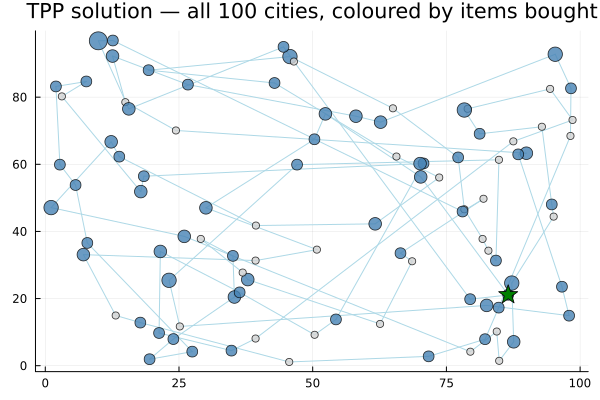

In [ ]:
# ── Visualise the solution ────────────────────────────────────────────────────

function plot_tpp_solution(X, Y, perm, items_bought_at)
    n = length(perm)
    items_per_city = zeros(Int, n)
    for city in items_bought_at
        items_per_city[city] += 1
    end

    plt = Plots.plot(title="TPP solution — all $n cities, coloured by items bought", legend=false)

    for i in 1:n
        a = perm[i]
        b = perm[mod1(i+1, n)]
        Plots.plot!(plt, [X[a], X[b]], [Y[a], Y[b]]; color=:lightblue, lw=1)
    end

    for city in 1:n
        cnt = items_per_city[city]
        col = cnt == 0 ? :lightgrey : :steelblue
        sz  = cnt == 0 ? 4 : 5 + cnt
        scatter!(plt, [X[city]], [Y[city]]; color=col, markersize=sz, alpha=0.8)
    end

    scatter!(plt, [X[perm[1]]], [Y[perm[1]]]; color=:green, markersize=10, markershape=:star5)
    return plt
end

_, best_travel, best_purchase, items_bought_at = decode_tpp(best_perm, d, cost_item_city)
plot_tpp_solution(X, Y, best_perm, items_bought_at)

## Experiment: population size & iterations

Run the GA with several configurations and collect results.

In [21]:
using Printf

configs = [
    (n=50,  k=20),
    (n=50,  k=50),
    (n=100, k=100),
]

POP = 1000
ITERS = 100

println("pop_size | iterations | best_cost  | travel    | purchase  | time(s)")
println(repeat("-", 68))

function tpp_cost(perm::Vector{Int}, d::Matrix{Float64}, cost_item_city::Matrix{Float64})
    _, travel, purchase, _ = decode_tpp(perm, d, cost_item_city)
    return travel + purchase
end


for cfg in configs
    n = cfg.n
    k = cfg.k
    for i in 1:3
        X, Y, d, cost_item_city = generate_random_tpp(n, k)
        println("Generated TPP: n=$n cities, k=$k items")

        x0 = collect(1:n)

        t0 = time()
        sol = Evolutionary.optimize(
            perm -> tpp_cost(perm, d, cost_item_city), 
            x0,
            GA(;
                populationSize = POP,
                crossover      = recombine_tpp,
                mutation       = mutate_swap_tpp,
                epsilon        = 0.01,
                crossoverRate  = 0.9,
                mutationRate   = 0.05,
            ),
            Evolutionary.Options(; iterations = ITERS),
        )
        
        elapsed = round(time() - t0, digits=1)
        _, tv, pv, _ = decode_tpp(sol.minimizer, d, cost_item_city)
        @printf("%8d | %10d | %10.2f | %9.2f | %9.2f | %7.1f\n",
            POP, ITERS, sol.minimum, tv, pv, elapsed)
    end
end

pop_size | iterations | best_cost  | travel    | purchase  | time(s)
--------------------------------------------------------------------
Generated TPP: n=50 cities, k=20 items
    1000 |        100 |    2247.92 |   1223.74 |   1024.17 |     1.2
Generated TPP: n=50 cities, k=20 items
    1000 |        100 |    2161.33 |   1137.15 |   1024.17 |     0.5
Generated TPP: n=50 cities, k=20 items
    1000 |        100 |    2225.07 |   1200.90 |   1024.17 |     0.5
Generated TPP: n=50 cities, k=50 items
    1000 |        100 |    3863.68 |   1290.36 |   2573.32 |     1.1
Generated TPP: n=50 cities, k=50 items
    1000 |        100 |    3759.52 |   1186.20 |   2573.32 |     0.7
Generated TPP: n=50 cities, k=50 items
    1000 |        100 |    3742.62 |   1169.29 |   2573.32 |     0.8
Generated TPP: n=100 cities, k=100 items
    1000 |        100 |    7776.85 |   2700.70 |   5076.15 |     2.8
Generated TPP: n=100 cities, k=100 items
    1000 |        100 |    7747.07 |   2670.92 |   5076.15 |   